<a href="https://colab.research.google.com/github/akshaykrishnas2200-cpu/Machine-learning/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# Load dataset
df = pd.read_csv("online_retail.csv")

In [4]:
# Inspect the first few rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Check dataset structure, data types, and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152755 entries, 0 to 152754
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    152755 non-null  object 
 1   StockCode    152755 non-null  object 
 2   Description  152131 non-null  object 
 3   Quantity     152755 non-null  int64  
 4   InvoiceDate  152755 non-null  object 
 5   UnitPrice    152755 non-null  float64
 6   CustomerID   105812 non-null  float64
 7   Country      152755 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 9.3+ MB


In [6]:
# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])
# Remove invalid transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
# Calculate total amount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [7]:
# Customer-level aggregation
customer_data = df.groupby("CustomerID").agg({
"Quantity": "sum",
"TotalAmount": "sum",
"InvoiceNo": "nunique"
}).reset_index()

In [8]:
customer_data.columns = [
"CustomerID", "TotalQuantity",
"TotalAmount", "NumberOfInvoices"
]

In [9]:
# Create customer segment
median_amount = customer_data["TotalAmount"].median()
customer_data["Segment"] = (
customer_data["TotalAmount"] >= median_amount
).astype(int)

In [10]:
# Features and target
X = customer_data[["TotalQuantity", "NumberOfInvoices"]]
y = customer_data["Segment"]

In [11]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:

# ID3 Decision Tree
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [13]:
# Prediction
y_pred = model.predict(X_test)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nFeature Importance:")
for feature, importance in zip(
    X.columns, model.feature_importances_
):
    print(feature, ":", round(importance, 4))

Decision Tree Accuracy: 86.95 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       226
           1       0.88      0.86      0.87       226

    accuracy                           0.87       452
   macro avg       0.87      0.87      0.87       452
weighted avg       0.87      0.87      0.87       452


Feature Importance:
TotalQuantity : 0.8671
NumberOfInvoices : 0.1329


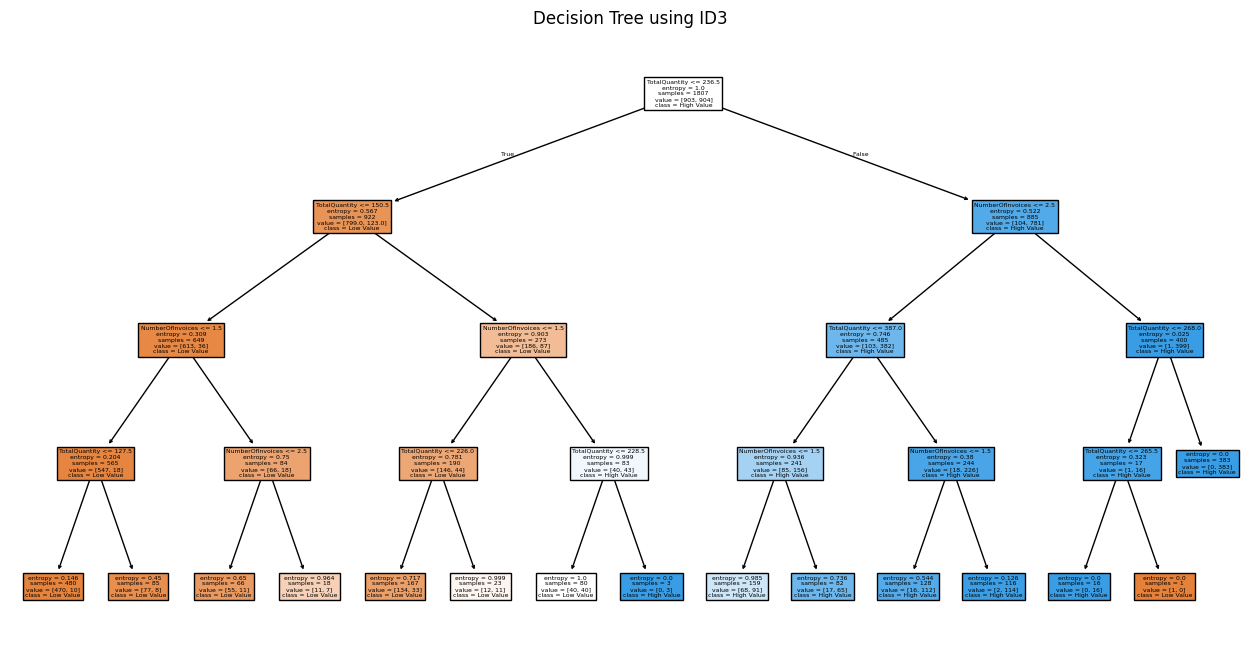

In [14]:

# Visualize tree
plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low Value", "High Value"],
    filled=True
)
plt.title("Decision Tree using ID3")
plt.show()